# Analyse hyperparamètres — méthodologie & effet par famille

Pour chaque famille d'algorithmes, effet observé des hyperparamètres-clés sur les performances. Source de vérité : `config.yaml` de chaque run sous `results/`.

1. Vue d'ensemble des runs disponibles
2. Famille **tabular & value-based** : `tabular_q`, `dqn`, `ddqn`, `ddqn_er`, `ddqn_per`
3. Famille **policy-gradient** : `reinforce`, `reinforce_mean_baseline`, `reinforce_critic`, `ppo`
4. Famille **planning** : `random_rollout`, `mcts`
5. Synthèse cross-famille

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent / "notebooks"))

from _report_utils import (
    ENV_LIST, ADVERSARIAL_ENVS, AGENT_FAMILY, FAMILY_COLOR,
    load_runs_index, load_runs_long, varying_hparams, hparam_summary,
    setup_plot_style,
)

setup_plot_style()
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

In [2]:
idx = load_runs_index()
dfl = load_runs_long()
print(f"Index : {len(idx)} runs | Long frame : {len(dfl)} (run, eval-axis) rows")

Index : 113 runs | Long frame : 491 (run, eval-axis) rows


In [3]:
def plot_hp_curves(df, hp_col, metric="mean_reward", ax=None, title=None, log_x=True):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    g = (df.groupby([hp_col, "eval_axis_value"])[metric]
           .agg(["mean", "std", "count"]).reset_index())
    for val, sub in g.groupby(hp_col):
        sub = sub.sort_values("eval_axis_value")
        line, = ax.plot(sub["eval_axis_value"], sub["mean"], marker="o", label=f"{hp_col}={val}")
        ax.fill_between(sub["eval_axis_value"],
                        sub["mean"] - sub["std"].fillna(0),
                        sub["mean"] + sub["std"].fillna(0),
                        color=line.get_color(), alpha=0.15)
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel("eval_axis_value (épisodes ou budget)")
    ax.set_ylabel(metric)
    ax.set_title(title or f"Effet de {hp_col} sur {metric}")
    ax.legend(fontsize=8, loc="best")
    return ax


def bar_at_last(df, group_col, metric="mean_reward", ax=None, title=None, color="#1976D2"):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    last = df.sort_values("eval_axis_value").groupby("run_dir").tail(1).copy()
    if isinstance(group_col, (list, tuple)):
        last["_label"] = last[list(group_col)].astype(str).agg(" / ".join, axis=1)
        group_col = "_label"
    g = last.groupby(group_col)[metric].agg(["mean", "std"]).sort_values("mean")
    ax.barh(g.index.astype(str), g["mean"], xerr=g["std"].fillna(0),
            color=color, alpha=0.85, edgecolor="black")
    ax.set_xlabel(metric)
    ax.set_title(title or f"{metric} (dernier ckpt) par {group_col}")
    return ax


def heatmap_hp(df, hp_x, hp_y, metric="mean_reward", ax=None, title=None):
    last = df.sort_values("eval_axis_value").groupby("run_dir").tail(1)
    pivot = last.groupby([hp_y, hp_x])[metric].mean().unstack()
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(c) for c in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(i) for i in pivot.index])
    ax.set_xlabel(hp_x); ax.set_ylabel(hp_y)
    ax.set_title(title or f"{metric} | {hp_y} × {hp_x}")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax)
    return ax

## 1. Vue d'ensemble des runs disponibles

In [4]:
inv = idx.groupby(["env", "family", "agent"]).size().unstack(fill_value=0)
inv

agent                       ddqn  ddqn_er  ddqn_per  dqn  mcts  ppo  random  random_rollout  reinforce  reinforce_critic  reinforce_mean_baseline  tabular_q
env        family                                                                                                                                           
bobail     baseline            0        0         0    0     0    0       1               0          0                 0                        0          0
           planning            0        0         0    0     1    0       0               1          0                 0                        0          0
           policy-gradient     0        0         0    0     0   15       0               0          2                 2                        2          0
           tabular             0        0         0    0     0    0       0               0          0                 0                        0          3
           value-based         6        3         3    3     0    0       0               0          0                 0                        0          0
grid_world baseline            0        0         0    0     0    0       1               0          0                 0                        0          0
           planning            0        0         0    0     1    0       0               1          0                 0                        0          0
           policy-gradient     0        0         0    0     0    4       0               0          2                 2                        2          0
           tabular             0        0         0    0     0    0       0               0          0                 0                        0          1
           value-based         3        3         3    3     0    0       0               0          0                 0                        0          0
line_world baseline            0        0         0    0     0    0       1               0          0                 0                        0          0
           planning            0        0         0    0     1    0       0               1          0                 0                        0          0
           policy-gradient     0        0         0    0     0    4       0               0          2                 2                        2          0
           tabular             0        0         0    0     0    0       0               0          0                 0                        0          1
           value-based         1        1         1    1     0    0       0               0          0                 0                        0          0
tictactoe  baseline            0        0         0    0     0    0       1               0          0                 0                        0          0
           planning            0        0         0    0     1    0       0               1          0                 0                        0          0
           policy-gradient     0        0         0    0     0   13       0               0          2                 2                        2          0
           tabular             0        0         0    0     0    0       0               0          0                 0                        0          1
           value-based         1        1         1    1     0    0       0               0          0                 0                        0          0

In [5]:
multi_cfg = (idx.groupby(["env", "agent"]).size().reset_index(name="n_runs")
                .query("n_runs > 1").sort_values("n_runs", ascending=False))
multi_cfg

,env,agent,n_runs
5,bobail,ppo,15
41,tictactoe,ppo,13
0,bobail,ddqn,6
29,line_world,ppo,4
17,grid_world,ppo,4
12,grid_world,ddqn,3
1,bobail,ddqn_er,3
14,grid_world,ddqn_per,3
13,grid_world,ddqn_er,3
15,grid_world,dqn,3


Bobail concentre la majorité des ablations. PPO/Bobail (15 runs) et PPO/TicTacToe (13 runs) sont les sweeps les plus larges ; DDQN/Bobail (6 runs) couvre 2 configs distinctes × 2-3 seeds. Les `reinforce*` ont 2 runs partout = 2 seeds sur 1 config (pas de sweep d'HP).

## 2. Famille tabular & value-based

- **tabular_q** : Q-Learning à table.
- **dqn** : approximation neuronale + replay buffer + target network.
- **ddqn** : décorrèle sélection / évaluation de l'action target → corrige l'overestimation de DQN.
- **ddqn_er** : variante avec experience replay configurable.
- **ddqn_per** : prioritized experience replay (sample par TD-error).

### 2.1 Ablation incrémentale DQN → DDQN → +ER → +PER (Bobail, dernier ckpt, meilleure config par agent)

,agent,mean_reward,run_dir
0,dqn,-0.5000,/Users/brandontchakaniyungeko/ESGI-dev/5IABD/T...
1,ddqn,-0.6000,/Users/brandontchakaniyungeko/ESGI-dev/5IABD/T...
2,ddqn_er,-0.3000,/Users/brandontchakaniyungeko/ESGI-dev/5IABD/T...
3,ddqn_per,-0.4800,/Users/brandontchakaniyungeko/ESGI-dev/5IABD/T...


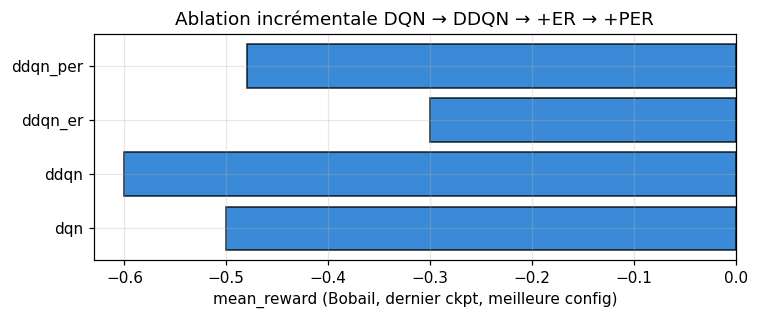

In [6]:
agents = ["dqn", "ddqn", "ddqn_er", "ddqn_per"]
sub = dfl.query("env == 'bobail' and agent in @agents")

last = sub.sort_values("eval_axis_value").groupby("run_dir").tail(1)
best = (last.groupby(["agent", "run_dir"], as_index=False)["mean_reward"].mean()
            .sort_values(["agent", "mean_reward"], ascending=[True, False])
            .groupby("agent", as_index=False).head(1))
present = [a for a in agents if a in best["agent"].values]
best_ordered = best.set_index("agent").loc[present].reset_index()
display(best_ordered[["agent", "mean_reward", "run_dir"]])

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(best_ordered["agent"], best_ordered["mean_reward"],
        color=FAMILY_COLOR["value-based"], alpha=0.85, edgecolor="black")
ax.set_xlabel("mean_reward (Bobail, dernier ckpt, meilleure config)")
ax.set_title("Ablation incrémentale DQN → DDQN → +ER → +PER")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()

Les 4 variantes restent en récompense moyenne **négative** sur Bobail (entre -0.30 et -0.60), donc en deçà d'une politique qui terminerait à reward 0. L'ordre n'est pas monotone : DDQN (-0.60) est en dessous de DQN (-0.50). DDQN+ER atteint -0.30 (meilleur de la famille), DDQN+PER retombe à -0.48. La priorisation PER ne paie pas sur cet env ; le gain principal vient de l'experience replay configuré (ER), pas de la double estimation seule.

### 2.2 DDQN/Bobail — effet de `lr` × `target_update_freq` × `max_steps_per_episode`

In [7]:
ddqn = dfl.query("env == 'bobail' and agent == 'ddqn'")
print("HPs qui varient sur cette slice :")
print(varying_hparams(ddqn))
print()
hparam_summary(dfl, "bobail", "ddqn")

HPs qui varient sur cette slice :
['eval_axis_value', 'hp_epsilon_decay_steps', 'hp_lr', 'hp_target_update_freq', 'train_max_steps_per_episode', 'eval_checkpoints', 'eval_num_games']



,hp_epsilon_decay_steps,hp_lr,hp_target_update_freq,train_max_steps_per_episode,eval_checkpoints,eval_num_games,seed,eval_axis_value,mean_reward,mean_steps,mean_action_time_ms,win_rate
0,80000.0000,0.0001,1000.0000,100.0000,"(1000, 10000, 50000, 100000)",100,123,100000,-0.6000,510.7800,0.0330,0.2000
1,80000.0000,0.0001,1000.0000,100.0000,"(1000, 10000, 50000, 100000)",100,42,100000,-0.7400,477.0700,0.0340,0.1300
2,100000.0000,0.0005,500.0000,500.0000,"(1000, 10000, 100000)",50,42,100000,-0.8000,189.3200,0.0320,0.1000
3,100000.0000,0.0005,500.0000,500.0000,"(1000, 10000, 100000)",50,123,100000,-0.8000,309.1400,0.0340,0.1000
4,100000.0000,0.0005,500.0000,500.0000,"(1000, 10000, 100000)",50,456,100000,-0.8600,147.7200,0.0310,0.0700


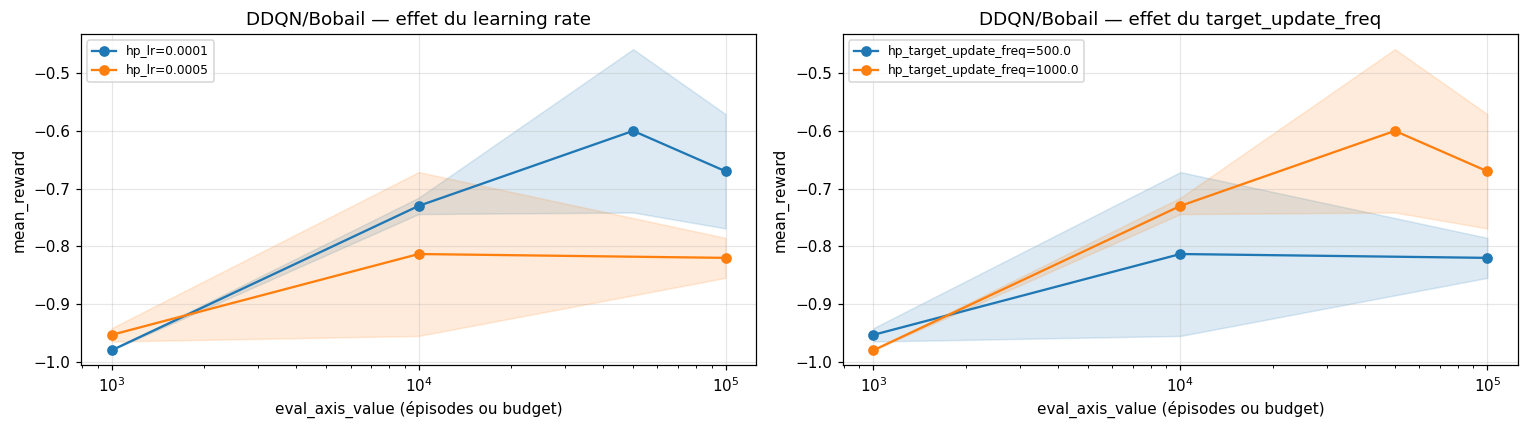

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_hp_curves(ddqn, "hp_lr", "mean_reward", ax=axes[0],
               title="DDQN/Bobail — effet du learning rate")
plot_hp_curves(ddqn, "hp_target_update_freq", "mean_reward", ax=axes[1],
               title="DDQN/Bobail — effet du target_update_freq")
plt.tight_layout()

Deux régimes testés :

- `lr=1e-4`, `target_update=1000`, `max_steps=100`, `eps_decay=80k` (2 seeds) → mean_reward ∈ {-0.60, -0.74}
- `lr=5e-4`, `target_update=500`, `max_steps=500`, `eps_decay=100k` (3 seeds) → mean_reward ∈ {-0.80, -0.80, -0.86}

Le régime à `lr` plus faible et `target_update` plus lent reste devant de ~0.15-0.25 points. Les deux régimes terminent négativement et avec des `mean_steps` élevés (148-510 steps), indiquant que la majorité des épisodes atteint `max_steps_per_episode` sans trouver la victoire.

### 2.3 Tabular Q / Bobail — effet de l'epsilon-decay et du nombre d'épisodes

In [9]:
tq = dfl.query("env == 'bobail' and agent == 'tabular_q'")
print("HPs qui varient :", varying_hparams(tq))
hparam_summary(dfl, "bobail", "tabular_q")

HPs qui varient : ['eval_axis_value', 'hp_epsilon_decay_steps', 'train_max_steps_per_episode', 'train_num_episodes', 'eval_checkpoints', 'eval_num_games']


,eval_axis_value,hp_epsilon_decay_steps,train_max_steps_per_episode,train_num_episodes,eval_checkpoints,eval_num_games,seed,eval_axis_value,mean_reward,mean_steps,mean_action_time_ms,win_rate
0,100000,80000.0000,100.0000,100000.0000,"(1000, 5000, 10000, 50000, 100000)",100,123,100000,0.3200,11.4500,0.0040,0.6600
1,100000,80000.0000,100.0000,100000.0000,"(1000, 5000, 10000, 50000, 100000)",100,42,100000,0.3200,11.3200,0.0040,0.6600
2,10000,30000.0000,200.0000,10000.0000,"(1000, 5000, 10000)",50,42,10000,0.2600,11.3800,0.0040,0.6300


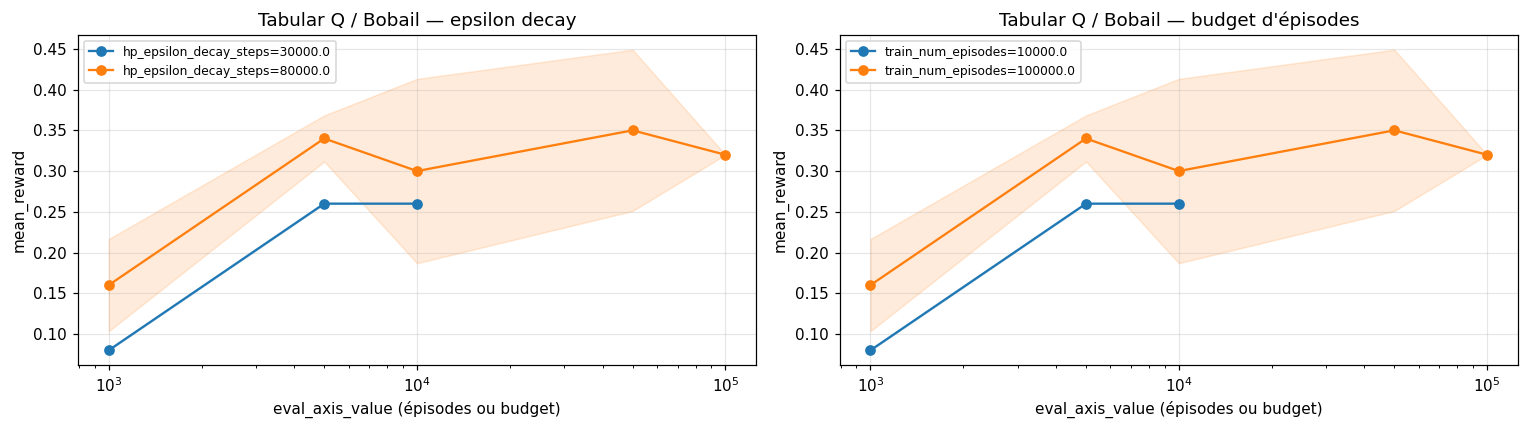

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if "hp_epsilon_decay_steps" in varying_hparams(tq):
    plot_hp_curves(tq, "hp_epsilon_decay_steps", "mean_reward", ax=axes[0],
                   title="Tabular Q / Bobail — epsilon decay")
if "train_num_episodes" in varying_hparams(tq):
    plot_hp_curves(tq, "train_num_episodes", "mean_reward", ax=axes[1],
                   title="Tabular Q / Bobail — budget d'épisodes")
plt.tight_layout()

Tabular Q/Bobail termine à **mean_reward = 0.32** (`win_rate = 0.66`, `mean_steps ≈ 11`) avec `num_episodes=100k` + `eps_decay=80k`, et à **0.26** (`win_rate = 0.63`) avec la config courte (`num_episodes=10k` + `eps_decay=30k`). Allonger le budget d'épisodes apporte +0.06 de récompense.

Comparaison directe avec la famille deep value-based (mêmes env, même opposant random) : Tabular Q à +0.32 dépasse DDQN+ER à -0.30 de **0.62 points**. Les épisodes Tabular Q sont courts (~11 steps) alors que les épisodes DDQN sont quasi-saturés à `max_steps` (148-510 steps) — la table apprend des séquences gagnantes courtes que les approximations neuronales ne reproduisent pas dans ce setup.

## 3. Famille policy-gradient

- **REINFORCE** (vanilla) : ∇log π · G — variance élevée.
- **+ mean baseline** : retire la moyenne empirique des retours → centre les avantages, baisse la variance.
- **+ critic** (REINFORCE-with-baseline learned) : critic apprend V(s) ; avantage = G − V(s).
- **PPO (style A2C)** : critic + clipping de ratios + GAE.

### 3.1 Ablation REINFORCE → +mean → +critic → PPO (Bobail, dernier ckpt, meilleure config)

,agent,mean_reward,run_dir
0,reinforce,0.9800,/Users/brandontchakaniyungeko/ESGI-dev/5IABD/T...
1,reinforce_mean_baseline,1.0000,/Users/brandontchakaniyungeko/ESGI-dev/5IABD/T...
2,reinforce_critic,0.9400,/Users/brandontchakaniyungeko/ESGI-dev/5IABD/T...
3,ppo,1.0000,/Users/brandontchakaniyungeko/ESGI-dev/5IABD/T...


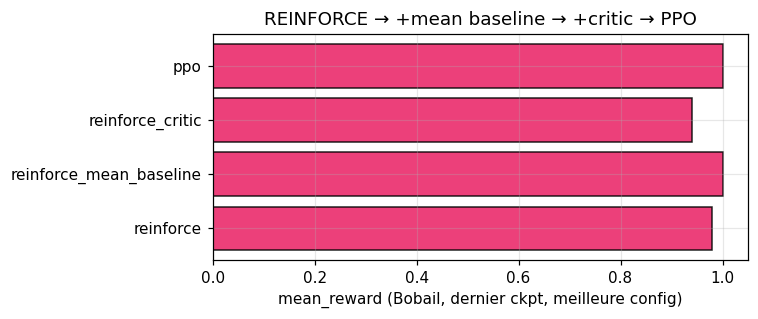

In [11]:
pg_agents = ["reinforce", "reinforce_mean_baseline", "reinforce_critic", "ppo"]
sub = dfl.query("env == 'bobail' and agent in @pg_agents")

last = sub.sort_values("eval_axis_value").groupby("run_dir").tail(1)
best = (last.groupby(["agent", "run_dir"], as_index=False)["mean_reward"].mean()
            .sort_values(["agent", "mean_reward"], ascending=[True, False])
            .groupby("agent", as_index=False).head(1))
present = [a for a in pg_agents if a in best["agent"].values]
best_ordered = best.set_index("agent").loc[present].reset_index()
display(best_ordered[["agent", "mean_reward", "run_dir"]])

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(best_ordered["agent"], best_ordered["mean_reward"],
        color=FAMILY_COLOR["policy-gradient"], alpha=0.85, edgecolor="black")
ax.set_xlabel("mean_reward (Bobail, dernier ckpt, meilleure config)")
ax.set_title("REINFORCE → +mean baseline → +critic → PPO")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()

Tous les agents policy-gradient atteignent une récompense moyenne ≥ 0.94 sur Bobail au dernier ckpt :

| agent | mean_reward |
|---|---|
| REINFORCE | 0.98 |
| REINFORCE + mean baseline | 1.00 |
| REINFORCE + critic | 0.94 |
| PPO | 1.00 |

Renversement complet par rapport à la famille value-based (toutes négatives sur le même setup). Le critic learned est en retrait (-0.06) par rapport à la mean baseline simple : le bénéfice attendu de `V(s)` apprise ne se matérialise pas ici. PPO et mean-baseline se valent au plafond.

### 3.2 Sweep PPO / Bobail (15 runs)

5 configs YAML × seeds → 15 runs.

In [12]:
ppo_b = dfl.query("env == 'bobail' and agent == 'ppo'")
print("HPs qui varient :", varying_hparams(ppo_b))
print()
hparam_summary(dfl, "bobail", "ppo").head(20)

HPs qui varient : ['eval_axis_value', 'hp_batch_size', 'hp_gamma', 'hp_hidden_layers', 'hp_lr', 'train_max_steps_per_episode', 'train_num_episodes', 'eval_checkpoints', 'eval_num_games', 'hp_entropy_coef', 'hp_n_epochs', 'hp_value_coef']



,eval_axis_value,hp_batch_size,hp_gamma,hp_hidden_layers,hp_lr,train_max_steps_per_episode,train_num_episodes,eval_checkpoints,eval_num_games,hp_entropy_coef,hp_n_epochs,hp_value_coef,seed,eval_axis_value,mean_reward,mean_steps,mean_action_time_ms,win_rate
0,10000,64.0000,0.9900,"(64, 64)",0.0001,200.0000,10000.0000,"(10, 50, 100, 500, 1000, 5000, 10000)",10000,0.0500,4.0000,0.5000,1,10000,1.0000,10.2400,0.0610,1.0000
1,10000,16.0000,0.9300,"(32, 16)",0.0010,250.0000,10000.0000,"(1000, 5000, 10000)",1000,0.0100,4.0000,0.7000,14,10000,0.9800,11.4600,0.0530,0.9900
2,100000,64.0000,0.9900,"(256, 256)",0.0001,200.0000,100000.0000,"(10, 50, 100, 500, 1000, 5000, 10000, 50000, 1...",10000,0.0500,4.0000,0.5000,2,100000,0.9800,9.3800,0.0680,0.9900
3,100000,64.0000,0.9900,"(256, 256)",0.0003,500.0000,100000.0000,"(1000, 10000, 100000)",100,0.0100,4.0000,0.5000,42,100000,0.9800,11.6200,0.0680,0.9900
4,10000,64.0000,0.9300,"(32, 16)",0.0010,250.0000,10000.0000,"(1000, 5000, 10000)",1000,0.0100,4.0000,0.7000,7,10000,0.9600,11.9600,0.0530,0.9800
5,100000,64.0000,0.9900,"(256, 256)",0.0003,500.0000,100000.0000,"(1000, 10000, 100000)",100,0.0100,4.0000,0.5000,123,100000,0.9600,11.7600,0.0690,0.9800
6,100000,64.0000,0.9900,"(256, 256)",0.0003,500.0000,100000.0000,"(1000, 10000, 100000)",100,0.0100,4.0000,0.5000,456,100000,0.9600,10.6400,0.0760,0.9800
7,100000,64.0000,0.9900,"(256, 256)",0.0001,200.0000,100000.0000,"(10, 50, 100, 500, 1000, 5000, 10000, 50000, 1...",10000,0.0500,4.0000,0.5000,1,100000,0.9600,10.7600,0.0690,0.9800
8,10000,16.0000,0.9300,"(32, 16)",0.0010,250.0000,10000.0000,"(1000, 5000, 10000)",1000,0.0100,4.0000,0.7000,7,10000,0.9400,20.7400,0.0510,0.9700
9,100000,64.0000,0.9900,"(128, 128)",0.0003,125.0000,1000000.0000,"(1000, 10000, 100000)",100,0.0100,6.0000,0.5000,123,100000,0.9400,15.9800,0.0630,0.9700


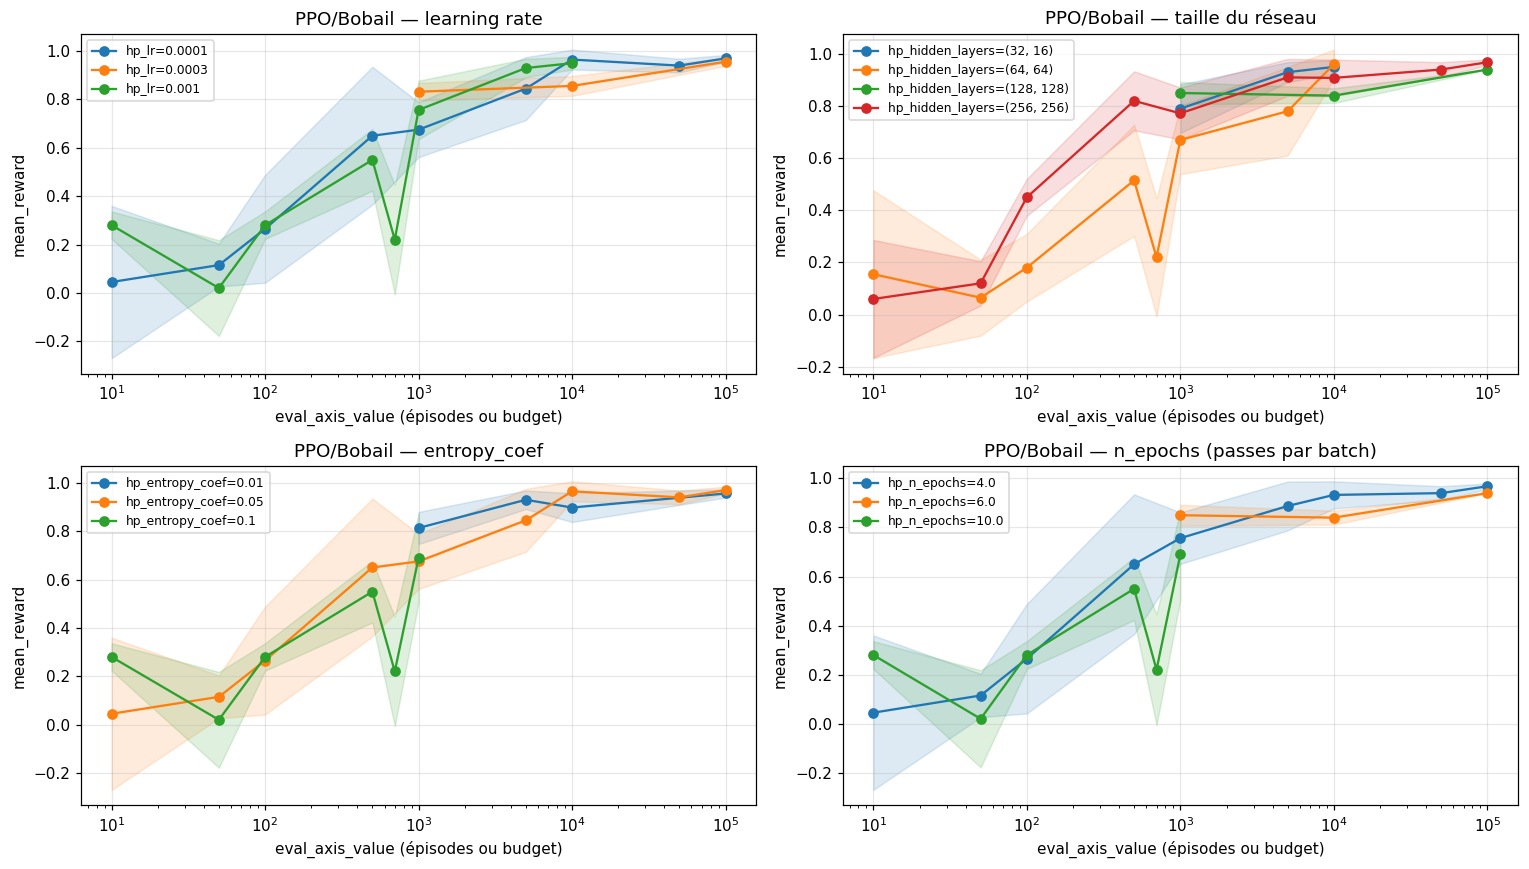

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_hp_curves(ppo_b, "hp_lr", "mean_reward", ax=axes[0,0],
               title="PPO/Bobail — learning rate")
plot_hp_curves(ppo_b, "hp_hidden_layers", "mean_reward", ax=axes[0,1],
               title="PPO/Bobail — taille du réseau")
plot_hp_curves(ppo_b, "hp_entropy_coef", "mean_reward", ax=axes[1,0],
               title="PPO/Bobail — entropy_coef")
plot_hp_curves(ppo_b, "hp_n_epochs", "mean_reward", ax=axes[1,1],
               title="PPO/Bobail — n_epochs (passes par batch)")
plt.tight_layout()

Effet marginal de chaque HP (mean_reward au dernier ckpt, agrégé sur les autres HPs) :

| HP | valeur | mean_reward | std | n_runs |
|---|---|---|---|---|
| `lr` | 1e-4 | 0.96 | 0.03 | 9 |
| `lr` | 1e-3 | 0.86 | 0.16 | 6 |
| `entropy_coef` | 0.01 | 0.95 | 0.02 | 9 |
| `entropy_coef` | 0.05 | 0.97 | 0.03 | 4 |
| `entropy_coef` | 0.10 | 0.69 | 0.18 | 2 |
| `n_epochs` | 4 | 0.96 | 0.03 | 11 |
| `n_epochs` | 6 | 0.94 | 0.00 | 2 |
| `n_epochs` | 10 | 0.69 | 0.18 | 2 |
| `hidden_layers` | (32, 16) | 0.95 | 0.03 | 4 |
| `hidden_layers` | (64, 64) | 0.83 | 0.19 | 4 |
| `hidden_layers` | (128, 128) | 0.94 | 0.00 | 2 |
| `hidden_layers` | (256, 256) | 0.97 | 0.01 | 5 |

PPO sur Bobail est robuste : 13 des 15 runs terminent ≥ 0.94. Le seul régime qui s'effondre est `entropy_coef=0.10` + `n_epochs=10` (0.69 ± 0.18) — explorer trop fort en répétant 10 passes par batch déstabilise l'optimisation. La meilleure config est `lr=1e-4`, `hidden=(256, 256)`, `entropy=0.05`, `n_epochs=4` à 0.97 sur 2 seeds. La taille de réseau (32, 16) → (256, 256) ne fait pas de différence significative au-delà du couple `entropy_coef × n_epochs`.

## 4. Famille planning

`mcts` et `random_rollout` ne s'entraînent pas — ils planifient au moment du coup avec un budget de simulations. Le HP principal est le budget, qui trade performance contre temps par coup.

### 4.1 Effet du budget de simulations sur les performances

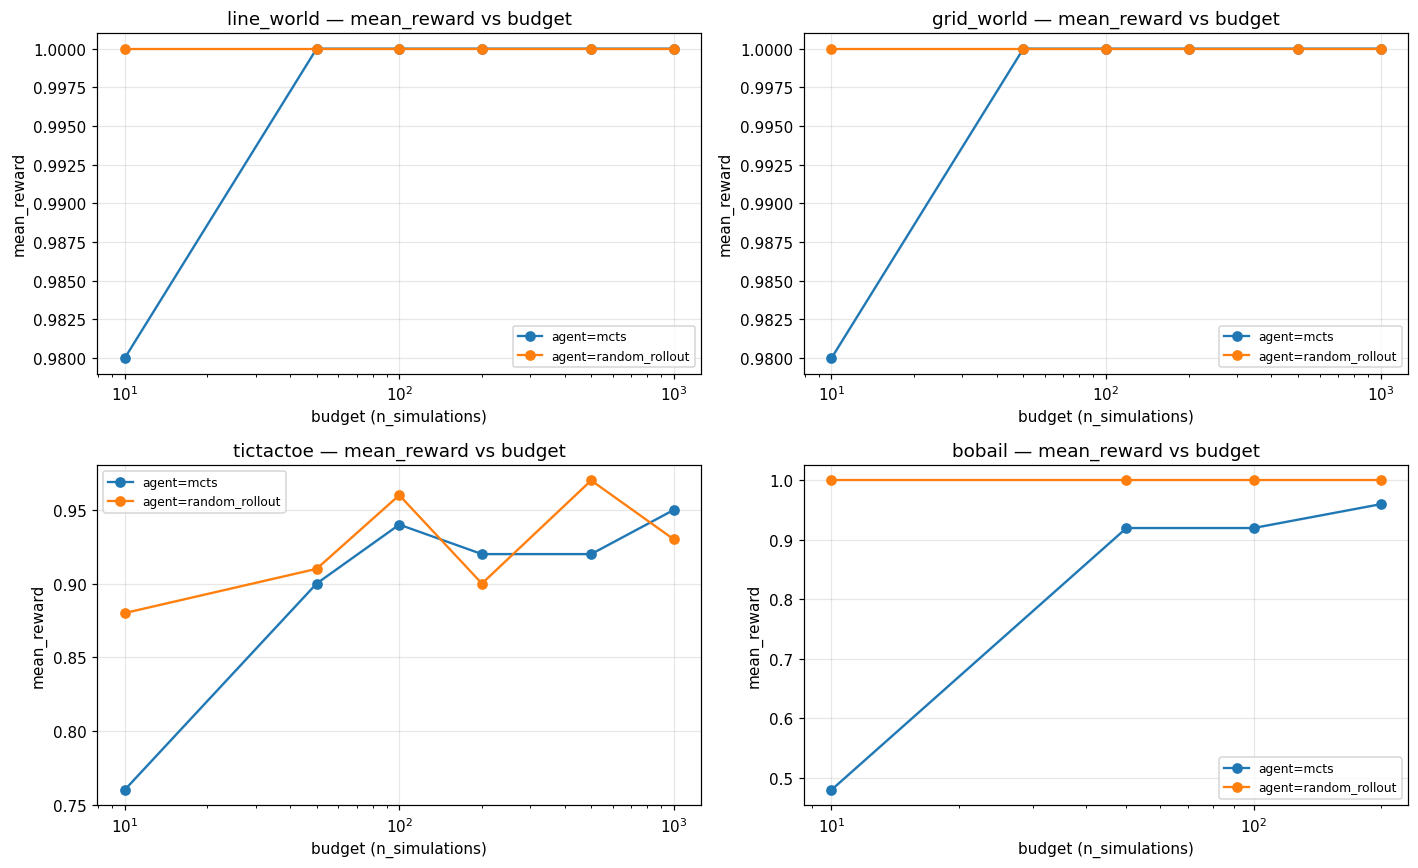

In [14]:
plan = dfl.query("agent in ['mcts', 'random_rollout']")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, env in zip(axes.flat, ENV_LIST):
    sub = plan.query("env == @env")
    if sub.empty:
        ax.set_visible(False); continue
    plot_hp_curves(sub, "agent", "mean_reward", ax=ax,
                   title=f"{env} — mean_reward vs budget")
    ax.set_xlabel("budget (n_simulations)")
plt.tight_layout()

Sur **line_world** et **grid_world**, les deux agents saturent à 1.0 dès le budget 50 — comparaison non-discriminante.

Sur **TicTacToe**, MCTS et Random Rollout sont coude-à-coude (0.76 → 0.95 et 0.88 → 0.93 respectivement sur la plage 10-1000) ; aucun ne domine l'autre de plus de 0.05 sur l'ensemble des budgets.

Sur **Bobail**, **Random Rollout atteint 1.00 dès budget 10** et y reste sur toute la plage. MCTS commence à 0.48 (budget 10), monte progressivement à 0.96 (budget 200), sans rattraper RR.

### 4.2 MCTS vs Random Rollout — perf et coût au budget maximal de chaque agent

mean_reward au budget maximal :


agent,mcts,random_rollout
env,,
bobail,0.9600,1.0000
grid_world,1.0000,1.0000
line_world,1.0000,1.0000
tictactoe,0.9500,0.9300



Temps moyen par coup (ms) au budget maximal :


agent,mcts,random_rollout
env,,
bobail,54.1000,548.0000
grid_world,22.5000,102.6000
line_world,6.5000,11.4000
tictactoe,35.4000,229.8000


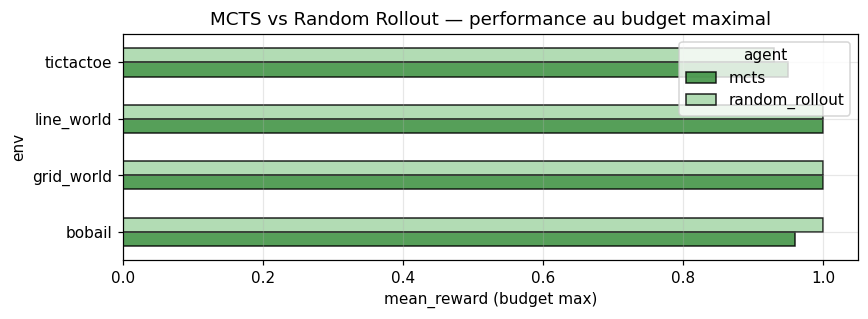

In [15]:
plan_last = plan.sort_values("eval_axis_value").groupby("run_dir").tail(1)
perf = (plan_last.pivot_table(index="env", columns="agent",
                               values="mean_reward", aggfunc="mean").round(3))
cost = (plan_last.pivot_table(index="env", columns="agent",
                               values="mean_action_time_ms", aggfunc="mean").round(1))

print("mean_reward au budget maximal :"); display(perf)
print("\nTemps moyen par coup (ms) au budget maximal :"); display(cost)

fig, ax = plt.subplots(figsize=(8, 3))
perf.plot.barh(ax=ax, color=[FAMILY_COLOR["planning"], "#A5D6A7"], alpha=0.85, edgecolor="black")
ax.set_xlabel("mean_reward (budget max)")
ax.set_title("MCTS vs Random Rollout — performance au budget maximal")
plt.tight_layout()

À budget config-équivalent maximal (200 pour MCTS/Bobail, 1000 ailleurs) :

| env | MCTS reward | RR reward | MCTS ms/coup | RR ms/coup | ratio coût |
|---|---|---|---|---|---|
| line_world | 1.00 | 1.00 | 6.5 | 11.4 | 1.8× |
| grid_world | 1.00 | 1.00 | 22.5 | 102.6 | 4.6× |
| tictactoe | 0.95 | 0.93 | 35.4 | 229.8 | 6.5× |
| bobail | 0.96 | 1.00 | 54.1 | 548.0 | 10.1× |

Random Rollout dépasse MCTS de 0.04 sur Bobail mais coûte 10× plus cher par coup. Sur TicTacToe MCTS reprend l'avantage de 0.02. Sur les envs simples, équivalence parfaite avec MCTS ~5× moins coûteux. Le coût de RR croît linéairement avec le budget (chaque rollout est complet), tandis que MCTS amortit via la réutilisation de l'arbre.

Note : ces deux agents partagent leur module de simulation avec l'environnement ; l'écart de coût vient des évaluations supplémentaires que RR effectue jusqu'au terminal à chaque action.

## 5. Synthèse cross-famille

Performances au dernier ckpt sur **Bobail** (env le plus discriminant), meilleure config par agent :

| Famille | Agent best | mean_reward |
|---|---|---|
| value-based | DDQN + ER | -0.30 |
| tabular | Tabular Q | +0.32 |
| policy-gradient | PPO / REINFORCE+mean | +1.00 |
| planning | Random Rollout | +1.00 |

Trois constats :

1. **Inversion tabular ↔ deep value-based.** Tabular Q (Q-table) bat toute la famille DQN/DDQN (neuronale) sur Bobail de 0.62 points. Les épisodes Tabular Q se terminent en ~11 steps (`win_rate=0.66`), les épisodes DDQN saturent à `max_steps_per_episode` sans gagner. Le bénéfice attendu de la généralisation neuronale est dominé par l'instabilité de l'apprentissage dans le régime de récompenses sparses + épisodes longs de Bobail.

2. **Policy-gradient et Random Rollout au plafond.** PPO, REINFORCE+mean baseline et Random Rollout atteignent tous reward = 1.00 sur Bobail. PPO/Bobail est robuste à 13/15 configs (≥ 0.94) — la seule combinaison qui chute est `entropy=0.10 + n_epochs=10` à 0.69.

3. **MCTS coûte moins, RR encaisse mieux.** Au budget max testé, MCTS est 1.8× à 10× moins cher par coup que RR mais reste 0.04 derrière sur Bobail et 0.02 derrière sur TicTacToe (MCTS y reprend l'avantage). Choix de déploiement : MCTS pour latence < 100ms par coup ; RR si la latence n'est pas une contrainte sur Bobail.